# Iris Classification Project
This notebook implements **Decision Trees** and **K-Nearest Neighbors** for the Iris Classification assignment.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, precision_score, recall_score
import os
from pathlib import Path

# Create visual directory if doesn't exist
os.makedirs("visualizations", exist_ok=True)

# 1. Load the dataset
print("--- Loading Dataset ---")
dataset_path = Path('iris_dataset.csv')
df = pd.read_csv(dataset_path)

# Features and target
X = df[['sepal_length', 'sepal_width', 'petal_length', 'petal_width']]
y = df['species']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
df.head()

--- Loading Dataset ---
Train size: 105, Test size: 45


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## Task 1: Decision Trees for Classification
- Train a Decision Tree.
- Visualize the tree structure.
- Prune the tree to prevent overfitting.
- Evaluate the model using Accuracy and F1-score.


--- Decision Tree Classification ---
Standard Decision Tree -> Accuracy: 0.9333, F1-score: 0.9327


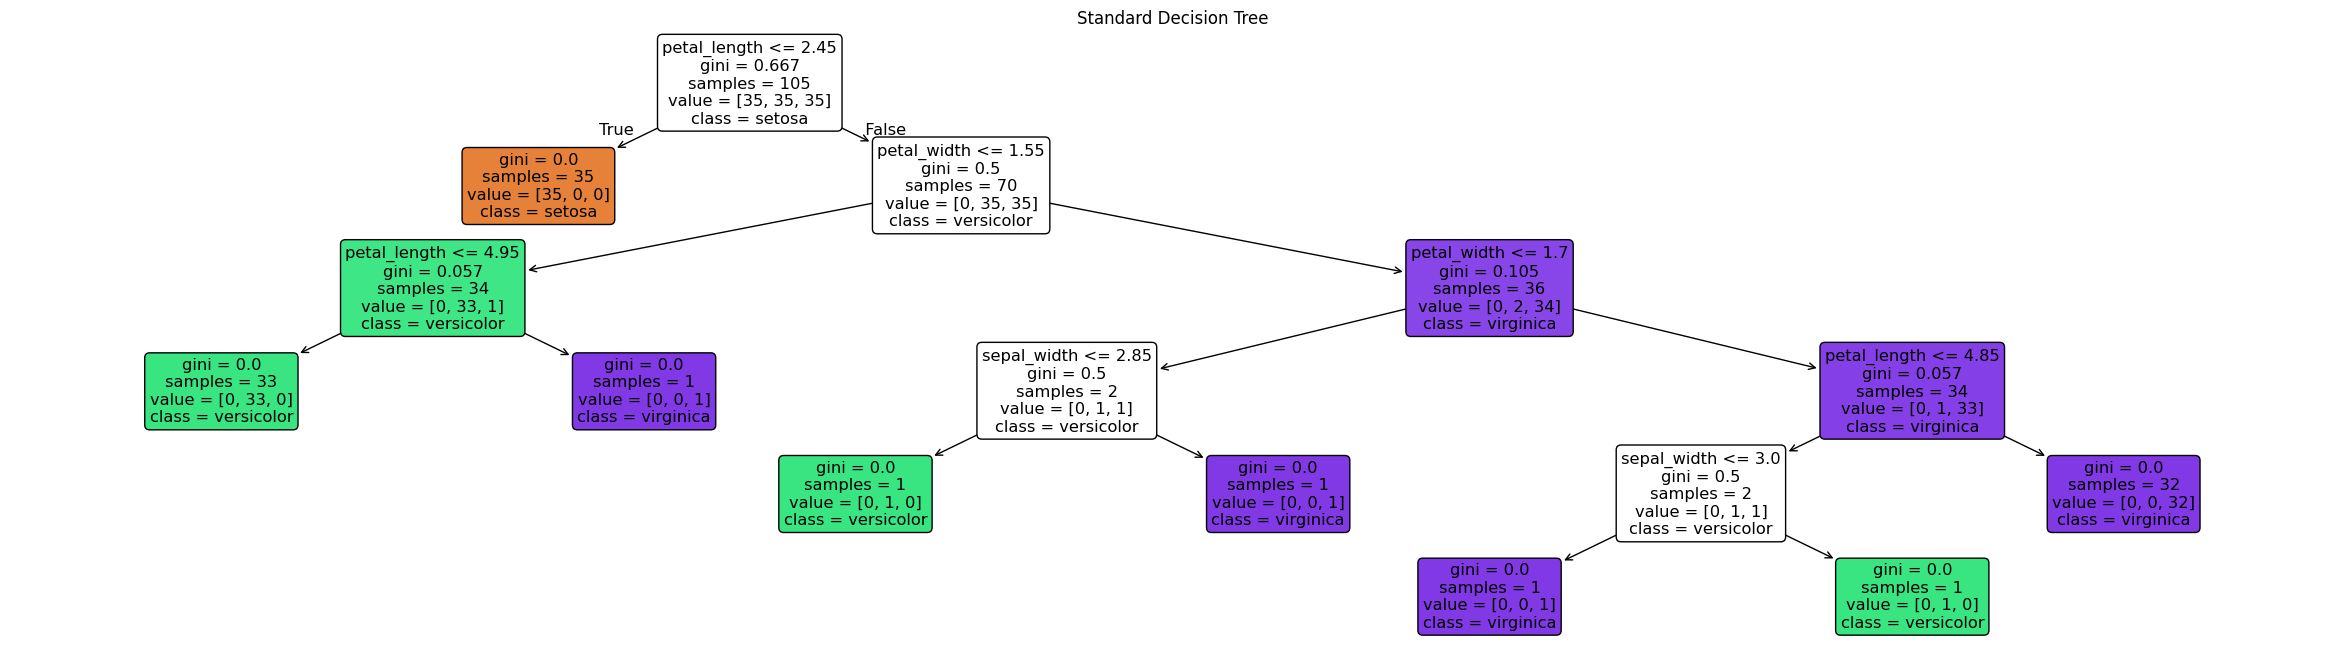

Pruning the tree to prevent overfitting...
Pruned Decision Tree -> Accuracy: 0.8889, F1-score: 0.8888


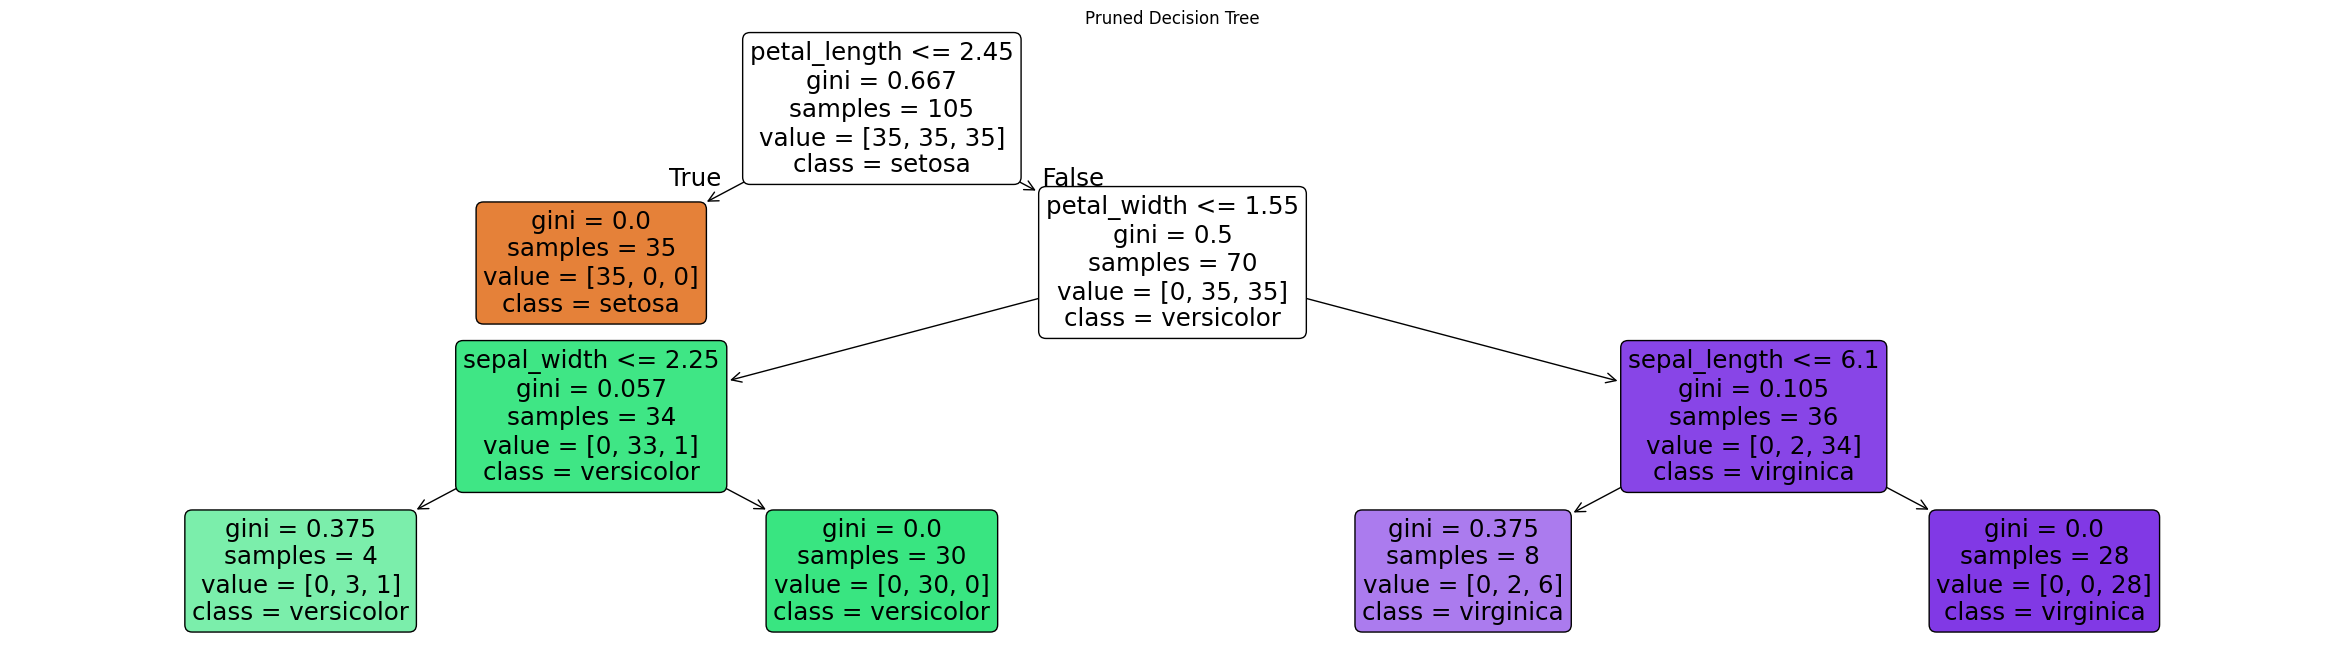

In [2]:
print("--- Decision Tree Classification ---")
# Train a standard decision tree
dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train, y_train)
y_pred_dt = dt_clf.predict(X_test)

# Evaluate
acc_dt = accuracy_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt, average='weighted')
print(f"Standard Decision Tree -> Accuracy: {acc_dt:.4f}, F1-score: {f1_dt:.4f}")

# Visualize structure
plt.figure(figsize=(30, 8))
plot_tree(dt_clf, feature_names=X.columns, class_names=dt_clf.classes_, filled=True, rounded=True)
plt.title("Standard Decision Tree")
plt.show()

# Pruning the tree (using max_depth or ccp_alpha)
print("Pruning the tree to prevent overfitting...")
pruned_dt_clf = DecisionTreeClassifier(random_state=42, max_depth=3, min_samples_leaf=4)
pruned_dt_clf.fit(X_train, y_train)
y_pred_pruned = pruned_dt_clf.predict(X_test)

# Evaluate Pruned Tree
acc_pruned = accuracy_score(y_test, y_pred_pruned)
f1_pruned = f1_score(y_test, y_pred_pruned, average='weighted')
print(f"Pruned Decision Tree -> Accuracy: {acc_pruned:.4f}, F1-score: {f1_pruned:.4f}")

plt.figure(figsize=(30, 8))
plot_tree(pruned_dt_clf, feature_names=X.columns, class_names=dt_clf.classes_, filled=True, rounded=True)
plt.title("Pruned Decision Tree")
plt.show()

## Task 2: K-Nearest Neighbors (KNN)
- Train a KNN model.
- Evaluate performance (Accuracy, Confusion Matrix, Precision/Recall).
- Compare different K values.


In [3]:
print("--- K-Nearest Neighbors Classification ---")
# Train a KNN model (k=5)
knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_train, y_train)
y_pred_knn = knn_clf.predict(X_test)

# Evaluate Performance
acc_knn = accuracy_score(y_test, y_pred_knn)
cm_knn = confusion_matrix(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn, average='weighted')
recall_knn = recall_score(y_test, y_pred_knn, average='weighted')

print(f"KNN (k=5) -> Accuracy: {acc_knn:.4f}")
print(f"Precision: {precision_knn:.4f}, Recall: {recall_knn:.4f}")
print("Confusion Matrix:")
print(cm_knn)

--- K-Nearest Neighbors Classification ---
KNN (k=5) -> Accuracy: 0.9778
Precision: 0.9792, Recall: 0.9778
Confusion Matrix:
[[15  0  0]
 [ 0 15  0]
 [ 0  1 14]]


Comparing different K values:


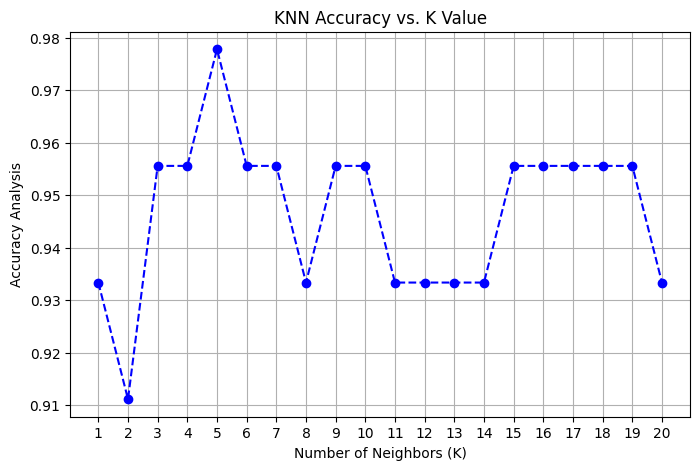

Best K value based on accuracy is K=5 with accuracy=0.9778


In [10]:
# Use different values of K and compare
print("Comparing different K values:")
k_values = range(1, 21)
accuracies = []

for k in k_values:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_train, y_train)
    y_pred_k = knn_k.predict(X_test)
    accuracies.append(accuracy_score(y_test, y_pred_k))
    
# Plot K values vs accuracy
plt.figure(figsize=(8, 5))
plt.plot(k_values, accuracies, marker='o', linestyle='dashed', color='b')
plt.title('KNN Accuracy vs. K Value')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Accuracy Analysis')
plt.xticks(k_values)
plt.grid(True)
plt.show()

# Find best K
best_k = k_values[accuracies.index(max(accuracies))]
print(f"Best K value based on accuracy is K={best_k} with accuracy={max(accuracies):.4f}")